In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [107]:
from apps.onpe.schemas import ConsultaElectoral
from apps.onpe.enums import Eleccion, AmbitoGeografico, UbigeoNivel1, TipoFiltro
import requests
from pydantic import BaseModel, computed_field, ConfigDict, Field, model_validator
from typing import Annotated, Self, Literal
from apps.onpe.client import get_resultados_onpe
import math
from apps.onpe.client import cookies, headers

def obtener_proyeccion_por_ubigeo(
    eleccion: Eleccion, ubigeo_list: List[UbigeoNivel1]
) -> pd.DataFrame:
    """
    Obtiene datos de cada ubigeo y calcula la proyección al 100%

    La fórmula es: Proyección = Total Votos Válidos Actuales / (Porcentaje de Actas / 100)
    """
    resultados = []

    for ubigeo in ubigeo_list:
        try:
            # Crear consulta
            consulta = ConsultaElectoral(eleccion=eleccion, ubigeo=ubigeo)

            # Obtener datos
            data_resumen = get_resultados_onpe(consulta, mode="resumen")["data"]
            data_detalle = get_resultados_onpe(consulta, mode="detalle")["data"]

            porcentaje_actas = data_resumen["actasContabilizadas"]

            # Procesar cada candidato
            for data in data_detalle:
                votos_actuales = data["totalVotosValidos"]
                if votos_actuales == 0:
                    continue  # Evitar división por cero

                # Calcular proyección al 100%
                if porcentaje_actas > 0:
                    proyeccion = int(votos_actuales / porcentaje_actas * 100)

                resultados.append(
                    {
                        "ubigeo": ubigeo.name,
                        "candidato": data["nombreAgrupacionPolitica"],
                        "votos_actuales": votos_actuales,
                        "proyeccion": proyeccion,
                    }
                )
        except Exception as e:
            print(f"Error procesando {ubigeo.name}: {str(e)}")
            continue

    return pd.DataFrame(resultados)

Obteniendo proyecciones para 29 ubigeos...
Esto puede tomar algunos minutos...
✓ Datos procesados: 1087 registros
✓ Ubigeos procesados: 29
Votos totales proyectados: 20.404.187
1er puesto proyectado: FUERZA POPULAR (14.35% | 2.927.511 votos)
2do puesto proyectado: VOTOS EN BLANCO (11.45% | 2.335.713 votos)
Brecha del 2do vs 1ro: 2.90 puntos porcentuales


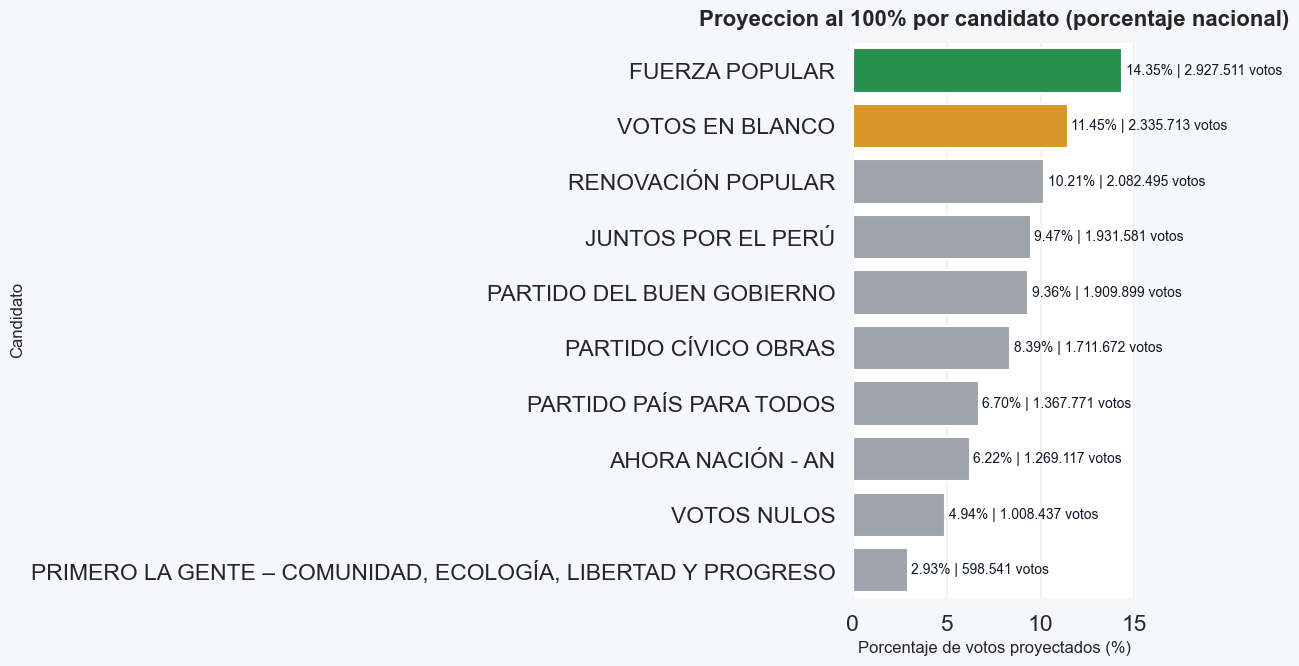

In [ ]:
# Obtener lista de ubigeos válidos para elecciones presidenciales
ubigeos_validos_presidencial = [
    ubigeo
    for ubigeo in list(UbigeoNivel1)
    if ubigeo
    not in [
        UbigeoNivel1.LIMA_METROPOLITANA,
        UbigeoNivel1.LIMA_PROVINCIAS,
        UbigeoNivel1.PERUANOS_RESIDENTES_EN_EL_EXTRANJERO,
        UbigeoNivel1.AFRICA
    ]
]

print(f"Obteniendo proyecciones para {len(ubigeos_validos_presidencial)} ubigeos...")
print("Esto puede tomar algunos minutos...")

# Obtener datos
df_proyecciones = obtener_proyeccion_por_ubigeo(
    Eleccion.PRESIDENCIAL, ubigeos_validos_presidencial
)

print(f"✓ Datos procesados: {len(df_proyecciones)} registros")
print(f"✓ Ubigeos procesados: {df_proyecciones['ubigeo'].nunique()}")

# Analisis principal: segundo puesto proyectado con porcentajes y votos totales
base = df_proyecciones.copy()
base['proyeccion'] = pd.to_numeric(base['proyeccion'], errors='coerce')
base = base.dropna(subset=['candidato', 'proyeccion'])

if base.empty:
    print('No hay datos suficientes para calcular la proyeccion.')
else:
    resumen = (
        base.groupby('candidato', as_index=False)['proyeccion']
        .sum()
        .sort_values('proyeccion', ascending=False)
        .reset_index(drop=True)
    )

    total = int(resumen['proyeccion'].sum())
    resumen['porcentaje'] = (resumen['proyeccion'] / total * 100).round(2)

    if len(resumen) < 2:
        print('Solo hay un candidato en los datos; no se puede calcular segundo puesto.')
    else:
        primero = resumen.iloc[0]
        segundo = resumen.iloc[1]
        brecha_pp = round(primero['porcentaje'] - segundo['porcentaje'], 2)

        print(f"Votos totales proyectados: {total:,}".replace(',', '.'))
        print(
            f"1er puesto proyectado: {primero['candidato']} "
            f"({primero['porcentaje']:.2f}% | {int(primero['proyeccion']):,} votos)".replace(',', '.')
        )
        print(
            f"2do puesto proyectado: {segundo['candidato']} "
            f"({segundo['porcentaje']:.2f}% | {int(segundo['proyeccion']):,} votos)".replace(',', '.')
        )
        print(f"Brecha del 2do vs 1ro: {brecha_pp:.2f} puntos porcentuales")

        # Grafico principal con enfoque en porcentaje y segundo puesto
        top_n = min(10, len(resumen))
        plot_df = resumen.head(top_n).copy()

        colors = ['#9ca3af'] * len(plot_df)
        colors[0] = '#16a34a'  # primer puesto
        colors[1] = '#f59e0b'  # segundo puesto

        plt.figure(figsize=(13, 7), facecolor='#f5f7fb')
        ax = sns.barplot(
            data=plot_df,
            x='porcentaje',
            y='candidato',
            palette=colors
        )

        for i, row in plot_df.iterrows():
            etiqueta = f"{row['porcentaje']:.2f}% | {int(row['proyeccion']):,} votos".replace(',', '.')
            ax.text(
                row['porcentaje'] + 0.18,
                i,
                etiqueta,
                va='center',
                fontsize=10,
                color='#111827'
            )

        ax.set_title('Proyeccion al 100% por candidato (porcentaje nacional)', fontsize=16, weight='bold', pad=12)
        ax.set_xlabel('Porcentaje de votos proyectados (%)', fontsize=12)
        ax.set_ylabel('Candidato', fontsize=12)
        ax.grid(axis='x', alpha=0.25)
        sns.despine(left=True, bottom=True)

        plt.tight_layout()
        plt.show()

Votos totales proyectados: 20.399.684
1er puesto proyectado: FUERZA POPULAR (14.35% | 2.927.492 votos)
2do puesto proyectado: VOTOS EN BLANCO (11.42% | 2.330.593 votos)
Brecha del 2do vs 1ro: 2.93 puntos porcentuales


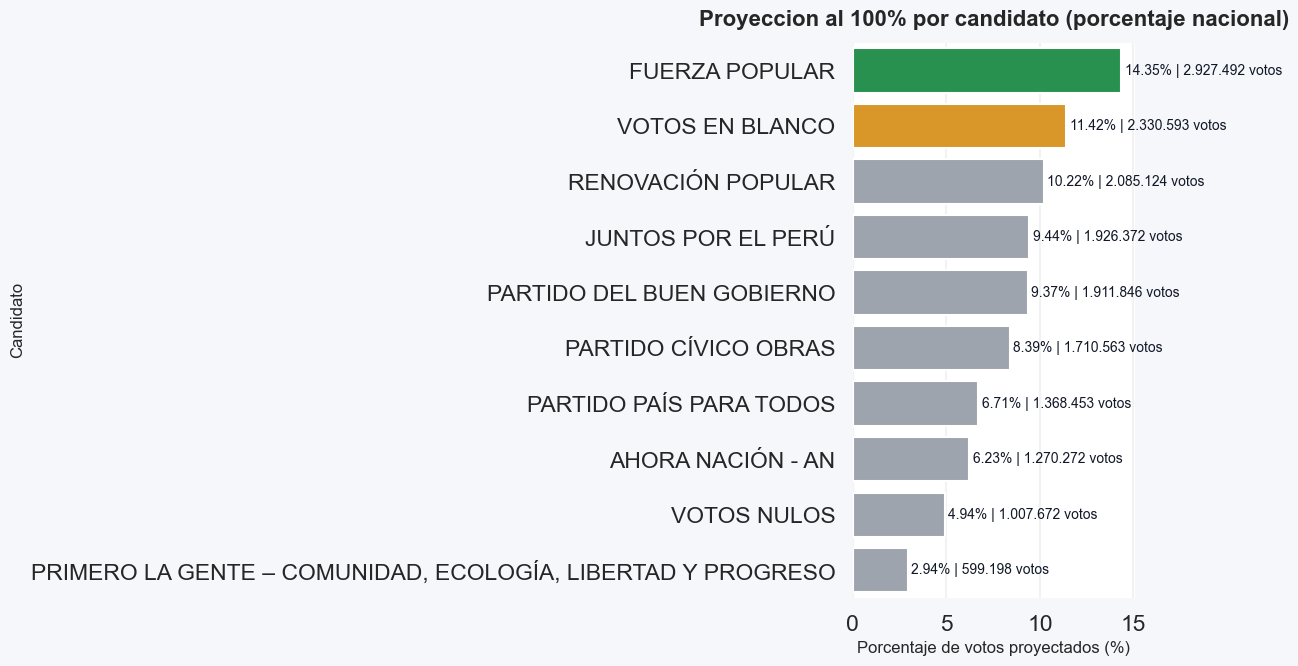

In [105]:
# Analisis principal: segundo puesto proyectado con porcentajes y votos totales
base = df_proyecciones.copy()
base['proyeccion'] = pd.to_numeric(base['proyeccion'], errors='coerce')
base = base.dropna(subset=['candidato', 'proyeccion'])

if base.empty:
    print('No hay datos suficientes para calcular la proyeccion.')
else:
    resumen = (
        base.groupby('candidato', as_index=False)['proyeccion']
        .sum()
        .sort_values('proyeccion', ascending=False)
        .reset_index(drop=True)
    )

    total = int(resumen['proyeccion'].sum())
    resumen['porcentaje'] = (resumen['proyeccion'] / total * 100).round(2)

    if len(resumen) < 2:
        print('Solo hay un candidato en los datos; no se puede calcular segundo puesto.')
    else:
        primero = resumen.iloc[0]
        segundo = resumen.iloc[1]
        brecha_pp = round(primero['porcentaje'] - segundo['porcentaje'], 2)

        print(f"Votos totales proyectados: {total:,}".replace(',', '.'))
        print(
            f"1er puesto proyectado: {primero['candidato']} "
            f"({primero['porcentaje']:.2f}% | {int(primero['proyeccion']):,} votos)".replace(',', '.')
        )
        print(
            f"2do puesto proyectado: {segundo['candidato']} "
            f"({segundo['porcentaje']:.2f}% | {int(segundo['proyeccion']):,} votos)".replace(',', '.')
        )
        print(f"Brecha del 2do vs 1ro: {brecha_pp:.2f} puntos porcentuales")

        # Grafico principal con enfoque en porcentaje y segundo puesto
        top_n = min(10, len(resumen))
        plot_df = resumen.head(top_n).copy()

        colors = ['#9ca3af'] * len(plot_df)
        colors[0] = '#16a34a'  # primer puesto
        colors[1] = '#f59e0b'  # segundo puesto

        plt.figure(figsize=(13, 7), facecolor='#f5f7fb')
        ax = sns.barplot(
            data=plot_df,
            x='porcentaje',
            y='candidato',
            palette=colors
        )

        for i, row in plot_df.iterrows():
            etiqueta = f"{row['porcentaje']:.2f}% | {int(row['proyeccion']):,} votos".replace(',', '.')
            ax.text(
                row['porcentaje'] + 0.18,
                i,
                etiqueta,
                va='center',
                fontsize=10,
                color='#111827'
            )

        ax.set_title('Proyeccion al 100% por candidato (porcentaje nacional)', fontsize=16, weight='bold', pad=12)
        ax.set_xlabel('Porcentaje de votos proyectados (%)', fontsize=12)
        ax.set_ylabel('Candidato', fontsize=12)
        ax.grid(axis='x', alpha=0.25)
        sns.despine(left=True, bottom=True)

        plt.tight_layout()
        plt.show()

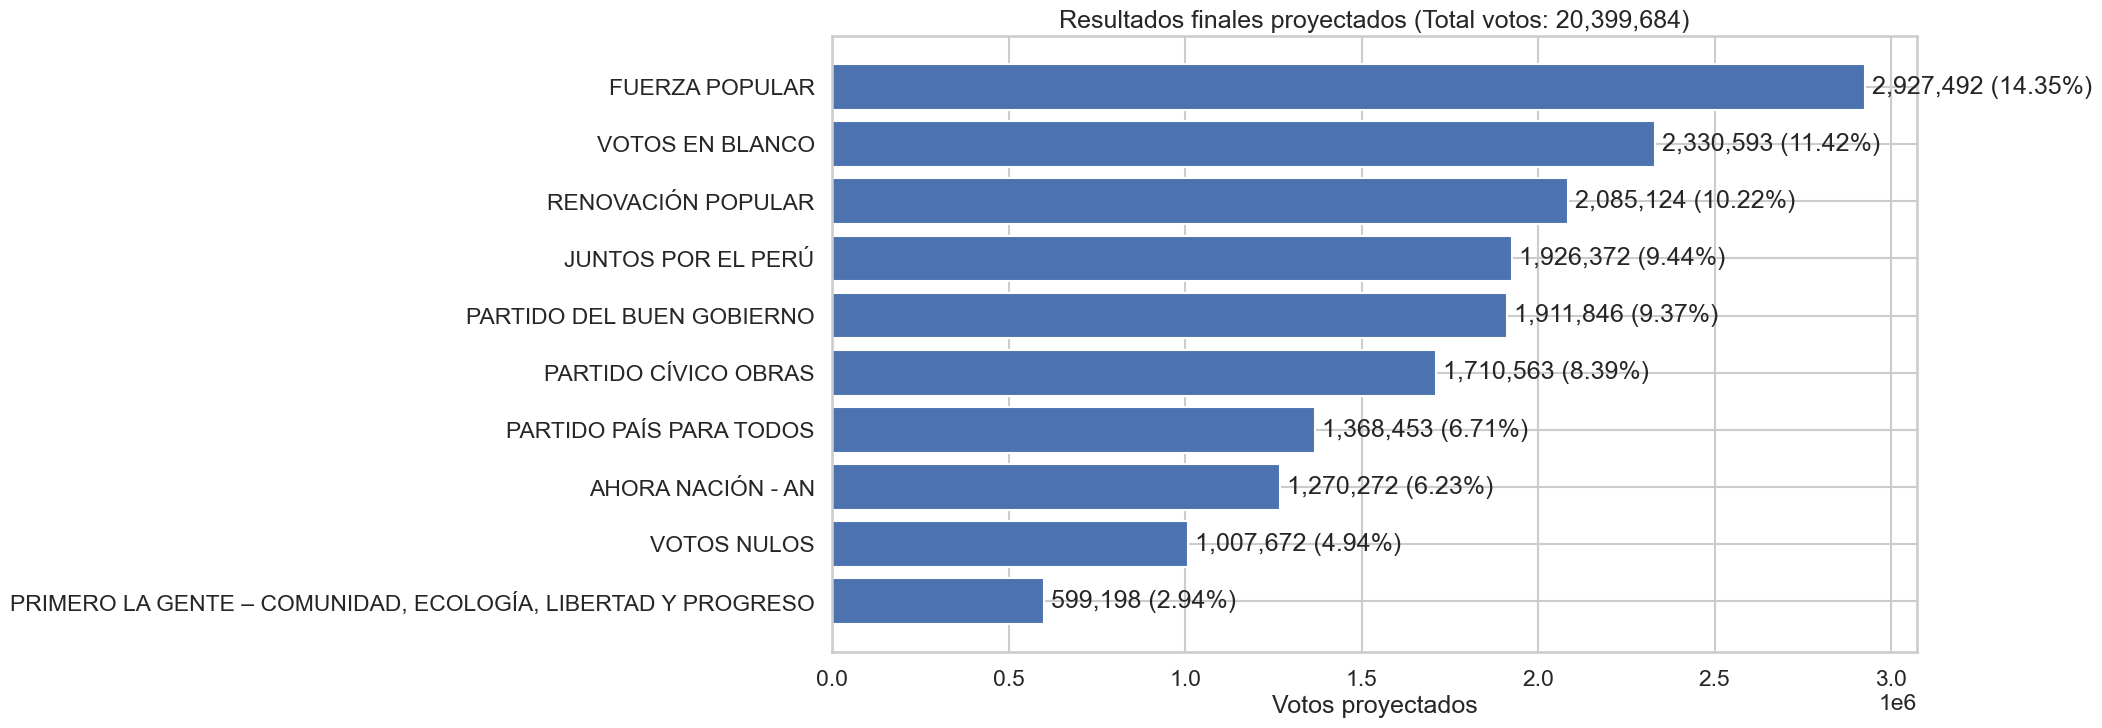

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Agrupar resultados finales
df_final = (
    df_proyecciones
    .groupby("candidato", as_index=False)["proyeccion"]
    .sum()
    .sort_values("proyeccion", ascending=False)
)

# 2. Calcular total y porcentaje
total_votos = df_final["proyeccion"].sum()
df_final["porcentaje"] = df_final["proyeccion"] / total_votos * 100

# 3. Opcional: top 10
df_top = df_final.head(10)

# 4. Gráfico
plt.figure()
bars = plt.barh(df_top["candidato"], df_top["proyeccion"])
plt.gca().invert_yaxis()

# 5. Etiquetas (votos + porcentaje)
for i, row in enumerate(df_top.itertuples()):
    plt.text(
        row.proyeccion,
        i,
        f" {row.proyeccion:,} ({row.porcentaje:.2f}%)",
        va='center'
    )

plt.xlabel("Votos proyectados")
plt.title(f"Resultados finales proyectados (Total votos: {total_votos:,})")

plt.show()